<a href="https://colab.research.google.com/github/Santhoshbabu009/192324146-ITA0604-MACHINE-LEARNING/blob/main/IDE_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


First 5 Records
  pH_Band Turbidity TDS_Band Residual_Chlorine Microbial       Source  \
0    High      High      Low               Low   Present         Lake   
1     Low      High     High            Normal    Absent  Groundwater   
2    High      High   Medium               Low   Present         Lake   
3    High       Low      Low               Low    Absent  Groundwater   
4     Low       Low      Low               Low   Present        River   

             Class  
0  Needs Treatment  
1  Needs Treatment  
2  Needs Treatment  
3  Needs Treatment  
4  Needs Treatment  

Confusion Matrix
[[18  0]
 [ 0  2]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Accuracy : 1.0
Precision: 1.0
R

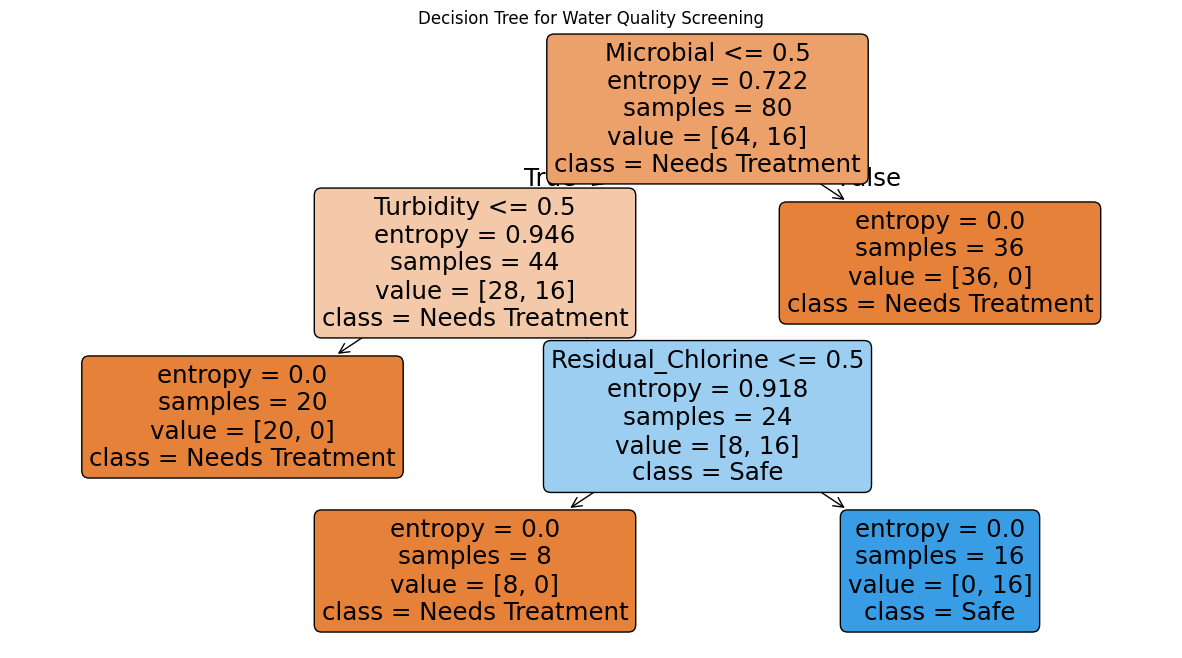

In [1]:
# ===========================================
# Safe Drinking Water Quality Screening
# Decision Tree Implementation
# ===========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

# -----------------------------
# Generate Synthetic Dataset
# -----------------------------
np.random.seed(42)

records = 100

data = {
    "pH_Band": np.random.choice(["Low", "Normal", "High"], records),
    "Turbidity": np.random.choice(["Low", "High"], records),
    "TDS_Band": np.random.choice(["Low", "Medium", "High"], records),
    "Residual_Chlorine": np.random.choice(["Low", "Normal"], records),
    "Microbial": np.random.choice(["Present", "Absent"], records),
    "Source": np.random.choice(
        ["River", "Lake", "Groundwater"], records
    )
}

df = pd.DataFrame(data)

# -----------------------------
# Create Target Label
# -----------------------------
def classify(row):
    if (
        row["Microbial"] == "Absent"
        and row["Turbidity"] == "Low"
        and row["Residual_Chlorine"] == "Normal"
    ):
        return "Safe"
    else:
        return "Needs Treatment"

df["Class"] = df.apply(classify, axis=1)

print("\nFirst 5 Records")
print(df.head())

# -----------------------------
# Encode Categorical Data
# -----------------------------
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

# -----------------------------
# Split Dataset
# -----------------------------
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Train Decision Tree
# -----------------------------
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# -----------------------------
# Decision Rules
# -----------------------------
print("\nDecision Tree Rules\n")

feature_names = X.columns

rules = export_text(
    model,
    feature_names=list(feature_names)
)

print(rules)

# -----------------------------
# Plot Decision Tree
# -----------------------------
plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=["Needs Treatment", "Safe"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Water Quality Screening")
plt.show()